# Embedding a neuron model in a network model

ISF defines network connectivity between presynaptic cells and a postsynaptic neuron model in terms of two files:
- The [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) defines the location of synapses onto a postsynaptic morphology, including the type of the corresponding presynaptic cell
- The [.con file](https://mpinb.github.io/in_silico_framework/file_formats#con) defines for each synapse the corresponding ID, and the presynaptic cell ID. Each presynaptic cell may have one or more synapses with the postsynaptic neuron.

ISF provides a way to generate this connectivity data based on an empirically quantified dense anatomical model. The pipeline for this is shown in [this section](#calculating-synapse-positions-on-the-neuron-morphology-from-empirical-data)

Many model systems do not have this data available, or infer connectivity from anatomical models in different ways. In those cases, we highly recommend to generate connectivity data (i.e. [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files) in whichever form is most suitable to your model system, depending on the available anatomical data, and convert the connectivity specification to those file formats. Both file formats are kept as simplistic as possible: human-readable ASCII text. To make this conversion as easy as possible, we outline exactly how these file formats work in the next sections.

## The [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn)

[.syn files](https://mpinb.github.io/in_silico_framework/file_formats#syn) define the location of synapses onto a postsynaptic morphology.
As such, they are only valid for one specific morphology.

Let's have a look at what exactly a [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) looks like.

In [179]:
from getting_started import example_data_dir
from pathlib import Path
example_embedding_dir = Path(example_data_dir) / "anatomical_constraints" / "example_embedding_86_C2_center" 

In [180]:
example_syn_fn = [e for e in example_embedding_dir.glob("*.syn")][0]
with open(example_syn_fn) as input_file:
    head = [next(input_file) for _ in range(10)]
print("".join(head))

# Synapse distribution file
# corresponding to cell: 86_C2_center
# Type - section - section.x

VPM_E1	112	0.138046479525
VPM_E1	130	0.305058053119
VPM_E1	130	0.190509288017
VPM_E1	9	0.368760777084
VPM_E1	110	0.0
VPM_E1	11	0.120662910562



The [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) consists of a three-line header, a blank line, and then the connectivity data.

The header of the [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) defines what the file is, to which morphology file this [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) belongs, and the names of the three columns:
- `Type`: the type of the presynaptic cell that connects with this synapse
- `section`: the section number of the postsynaptic morphology where this synapse connects
- `section.x`: the relative coordinate on this section where this synapse connects

Each line corresponds to a single synapse. Each synapse has an ID that equals the index of this line, starting at 0.

A single [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) uniquely defines, for one morphology, where each synapse is located on the dendritic tree, and what the corresponding presynaptic cell type is for each synapse.

## The [.con file](https://mpinb.github.io/in_silico_framework/file_formats#con)

A [.con file](https://mpinb.github.io/in_silico_framework/file_formats#con) defines to which presynaptic cell each synapse belongs.

In [181]:
example_con_fn = [e for e in example_embedding_dir.glob("*.con")][0]
with open(example_con_fn) as input_file:
    head = [next(input_file) for _ in range(10)]
print("".join(head))

# Anatomical connectivity realization file; only valid with synapse realization:
# example_embedding_86_C2_center.syn
# Type - cell ID - synapse ID

L6cc_A3	0	0
L6cc_A3	1	1
L6cc_A3	2	2
L6cc_A3	3	3
L6cc_A3	4	4
L6cc_A3	4	5



We see that the [.con file](https://mpinb.github.io/in_silico_framework/file_formats#con) again describes a three-line header. This time, it backlinks to a [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) and again defines three columns:
- `Type`: the type of the presynaptic cell this synapse belongs to. It is added for redundancy, so that this file is interpretable in isolation.
- `cell ID`: the ID of the presynaptic cell this synaps belongs to. This is not necessarily the same as the ID of the synapse. The same cell can make multiple synaptic connections with a postsynaptic neuron. These IDs are only the same if each synapse belongs to a unique presynaptic cell.
- `synapse ID`: the ID of this synapse. This corresponds to the row index in a [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn). This also explains why the corresponding [.syn file](https://mpinb.github.io/in_silico_framework/file_formats#syn) is mentioned in the header.

[.con files](https://mpinb.github.io/in_silico_framework/file_formats#con) provide some redundant information when combined with [.syn files](https://mpinb.github.io/in_silico_framework/file_formats#syn). This is simply to keep these files interpretable and informative when viewed in isolation.

## The [network parameters](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters)

[Network parameters](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters) define all parameters that relate to a network; both connectivity (this tutorial) and activity ([next tutorial](./2.2%20Network%20activity.ipynb)). The [next tutorial](./2.2%20Network%20activity.ipynb) will build a fully functional [network parameters](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters) that can be used for simulations of network-embedded neuron models. 

For the sake of completeness, we already show here how to build one containing just connectivity info.

In [182]:
from singlecell_input_mapper.network_param_builder import NetworkParamBuilder

netp = NetworkParamBuilder().add_network_embedding(
    syn_fn = example_syn_fn,
    con_fn = example_con_fn,
    join="right"  # right-join the incoming connectivity data to the network parameters (default is left)
)

netp.network_parameters.as_dict()

{'info': {'date': '2026-04-14', 'name': 'meulemeester'},
 'network': {'L1_B1': {'cellNr': 8,
   'synapses': {'distributionFile': PosixPath('/gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/getting_started/example_data/anatomical_constraints/example_embedding_86_C2_center/example_embedding_86_C2_center.syn'),
    'connectionFile': PosixPath('/gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/getting_started/example_data/anatomical_constraints/example_embedding_86_C2_center/example_embedding_86_C2_center.con')}},
  'L1_B2': {'cellNr': 10,
   'synapses': {'distributionFile': PosixPath('/gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/getting_started/example_data/anatomical_constraints/example_embedding_86_C2_center/example_embedding_86_C2_center.syn'),
    'connectionFile': PosixPath('/gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/getting_started/example_data/anatomical_constraints/example_embedding_86_C2_center/examp

We can see how the [Network parameters](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters) simply contain references to these [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files.
This information is defined for each cell type separately, allowing the user to specify additional cell types post-hoc, with additional and separate [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files. However, for many use cases, it is sufficient to define all connectivity in a single [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) file.

## Embedding a neuron model into a network model

This section covers the ISF pipeline to calculate synapse positions on the neuron morphology from empirical data
This pipeline has been described in detail in [Udvary et al. (2022)](https://doi.org/10.1016/j.celrep.2022.110677). 

> This is one of many methods in which you can infer synapse locations onto a postsynaptic morphology. If you do not have the required input data for this method, or you have your own methods, you can still use ISF! Familiarize yourself with the network connectivity file formats used in ISF: [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con)

The data requirements for this pipeline are:
- 3D density distribution of synapses across the neuropil
- Density of postsynaptic targets on the postsynaptic cell type, in units of length and area
- Amount of cells per cell type across the neuropil
- Locations of boutons in the neuropil, per cell type

We provide a dense model that contains this data for the rat barrel cortex, which you can download from [Harvard Dataverse](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/JZPULN):

```shell
pixi run download_bc_model
```

We explore the input data provided by this model and its formats in [this auxiliary tutorial](../auxiliary%20notebooks/A.3%20Udvary%202022.ipynb). 
For an interactive exploration of this model, please visit [cortexinsilico.mpinb.mpg](https://cortexinsilico.mpinb.mpg.de/)

In [183]:
# Check if the model is downloaded
from os.path import exists as path_exists, join as path_join, expandvars
assert path_exists(expandvars(path_join("$ISF_HOME", "barrel_cortex"))), "Please download the barrel cortex model first by running pixi r download_bc_model"

To get started, adapt the desired output directory below:

In [184]:
from pathlib import Path
tutorial_output_dir = f"{Path.home()}/isf_tutorial_output"  # <-- Change this to your desired output directory

In [185]:
%matplotlib inline
import Interface as I
from getting_started import getting_started_dir

example_data_dir = I.os.path.join(getting_started_dir, 'example_data')
db = I.DataBase(tutorial_output_dir).create_sub_db("network_modeling")

The first step to embedding a neuron model into a network model, is to align the reference frames of both.

From external resources (e.g. the NeuroMorph pipeline), you need a morphology `.hoc`-file. The coordinates in the hoc morphology file need to be anchored at the desired location.

As an example, we provide such file of a Layer-5 Pyramidal Tract Neuron (L5PT), whose coordinates are anchored in the C2 column of a rat barrel cortex (BC)

In [186]:
anatomy_dir = I.os.path.join(example_data_dir, 'anatomical_constraints')
I.os.listdir(anatomy_dir)

['86_C2_center_scaled_diameters.swc',
 'presynaptic_somata_soma_locations.csv',
 '86_C2_center.hoc',
 '89_C2.swc',
 '89_C2.hoc',
 '86_C2_center.swc',
 '86_C2_center_scaled_diameters.hoc',
 'example_embedding_86_C2_center']

In [187]:
path_to_hoc = I.os.path.join(
    anatomy_dir,
    '86_C2_center.hoc')
path_to_scaled_hoc = I.os.path.join(
    anatomy_dir,
    '86_C2_center_scaled_diameters.hoc')

assert I.os.path.exists(path_to_hoc)
assert I.os.path.exists(path_to_scaled_hoc)

We copy these morphology files to our DataBase.

In [188]:
if not 'anatomical_constraints' in db.keys():
    db.create_managed_folder('anatomical_constraints')
I.shutil.copy(path_to_hoc, db['anatomical_constraints'])
I.shutil.copy(path_to_scaled_hoc, db['anatomical_constraints'])

'/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center_scaled_diameters.hoc'

We use [`singlecell_input_mapper`](../singlecell_input_mapper/__init__.py) to create an anatomical embedding.
Under the hood, multiple anatomical embeddings will be calculated, all constrained with the same input data. 
From this distribution of anatomical realizations, the one that is closest to the average is chosen, which can be refered to as a "representative realization". The result is saved in the same folder as the hoc morphology. This takes very long to compute (up to 4 hours), but you can continue with a precomputed result.

For a given [morphology file](https://mpinb.github.io/in_silico_framework/file_formats#morphology), a network embedding is fully defined by a [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) file. 
The former to specify the locations fo the synapses onto the morphology, and the latter to specify their presynaptic origin.

### Computing it yourself

Here, we only use $1$ sample. 
This is not enough to get a sufficiently large distribution to draw a representative sample from. In our experience, $50$ samples is about enough to get a convergent distribution of synapse embeddings.

A sample size of $1$ is however sufficient for the sake of this tutorial.

In [189]:
celltype = 'L5tt'  # Layer 5 thick-tufted
morphology_fn = db['anatomical_constraints'].join('86_C2_center.hoc')

I.logger.setLevel("INFO") # verbose output
I.map_singlecell_inputs(
    cellName=morphology_fn, 
    cellTypeName=celltype,
    nrOfSamples=1  # <--- Increase this number to get more samples. ~50 is sufficient for convergence
)
I.logger.setLevel("WARNING")

[INFO] udvary2022: No numberOfCellsSpreadsheetName passed. Falling back to user-configured one.
[INFO] udvary2022: No connectionsSpreadsheetName passed. Falling back to user-configured one.
[INFO] udvary2022: No ExPSTDensityName passed. Falling back to user-configured one.
[INFO] udvary2022: No InhPSTDensityName passed. Falling back to user-configured one.
[INFO] udvary2022: No boutonDensityFolderName passed. Falling back to user-configured one.
[INFO] udvary2022: Loading cell morphology
[INFO] reader: Reading hoc file: /gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center.hoc
[INFO] udvary2022: Loading spreadsheets and bouton/PST densities...
[INFO] udvary2022:     Loading numberOfCells spreadsheet /gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/barrel_cortex/nrCells.csv
[INFO] udvary2022:     Loading bouton densities from folder /gpfs/soma_fs/scratch/meulemeester/project_src/in_silico_framework/barrel_cortex/sin

In [ ]:
# Adapt the path if you have generated a new anatomical model
path_to_anatomical_model = sorted(I.glob.glob(db['anatomical_constraints'].join('*_center_synapses*')))[-1]
print("Saved embedding results to: ", path_to_anatomical_model)

Saved embedding results to:  /gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center_synapses_20260319-1801_4193665


### Copying a pre-computed result instead

In [ ]:
# Pre-computed result: --------------------
from distutils.dir_util import copy_tree
path_to_anatomical_model = I.os.path.join(anatomy_dir, "example_embedding_86_C2_center")
copy_tree(path_to_anatomical_model, db['anatomical_constraints'])
path_to_anatomical_model = db['anatomical_constraints']

### Parallelizing the generation of anatomical models

We can use a dask `Client` to create our [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files for one morphology per process. This takes as long as creating an anatomical realization for a single cell, but thanks to parallellization, not much longer than that. At least, until the amount of cells exceed the amount of available threads.

In [ ]:
morphology_paths = [db['anatomical_constraints'].join(f) for f in db['anatomical_constraints'].listdir() if f.endswith('.hoc')]
morphology_paths

client = I.get_client(timeout=10)
client

Client Scheduler: tcp://10.100.2.217:38786 Dashboard: http://10.100.2.217:38787/status,Cluster Workers: 8 Cores: 8 Memory: 128.85 GB


In [ ]:
delayed_map_singlecell_inputs = I.dask.delayed(I.map_singlecell_inputs)  # make the single cell mapper a delayed function
delayeds = [delayed_map_singlecell_inputs(p, 'L5tt') for p in morphology_paths] # call it with the morphologies
delayeds = I.dask.delayed(delayeds) # bundle everything in one delayed object
futures = client.compute(delayeds)  # compute the result

You can restart the client to interrupt this computation if don't want to compute this right now

In [ ]:
client.restart()

Client Scheduler: tcp://10.100.2.217:38786 Dashboard: http://10.100.2.217:38787/status,Cluster Workers: 8 Cores: 8 Memory: 128.85 GB


Let's move the results of our synapse embedding to the database for convenience during this tutorial

In [ ]:
# Let's first unpack the re
I.shutil.copytree(path_to_anatomical_model, I.os.path.dirname(path_to_anatomical_model), dirs_exist_ok=True)
I.shutil.rmtree(path_to_anatomical_model)

## Inspecting the output

In the directory generated by the singlecell_input_mapper, there are the following files:

In [11]:
db['anatomical_constraints'].listdir()

['Loader.json',
 'example_embedding_86_C2_center.con',
 'NumberOfConnectedCells.csv',
 '86_C2_center.hoc',
 'example_embedding_86_C2_center.syn',
 'example_embedding',
 'metadata.json',
 '86_C2_center_scaled_diameters.hoc']

The most important files for making single-cell simulations are [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files. The others are useful for analysis, but are not required for further use in ISF.

In [11]:
con_file = db['anatomical_constraints'].get_file('.con')
con_file_path = db['anatomical_constraints'].join(con_file)
with open(con_file_path) as f:
    print(f.read()[:300])

# Anatomical connectivity realization file; only valid with synapse realization:
# example_embedding_86_C2_center.syn
# Type - cell ID - synapse ID

L6cc_A3	0	0
L6cc_A3	1	1
L6cc_A3	2	2
L6cc_A3	3	3
L6cc_A3	4	4
L6cc_A3	4	5
L6cc_A3	5	6
L6cc_A3	6	7
L6cc_A3	7	8
L6cc_A3	7	9
L6cc_A3	8	10
L6cc_A3	9	11
L6cc_


The [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) file specifies the exact position of each synapse on the hoc morphology:

In [12]:
syn_file_path = db['anatomical_constraints'].join(db['anatomical_constraints'].get_file('.syn'))
with open(syn_file_path) as f:
    print(f.read()[:300])

# Synapse distribution file
# corresponding to cell: 86_C2_center
# Type - section - section.x

VPM_E1	112	0.138046479525
VPM_E1	130	0.305058053119
VPM_E1	130	0.190509288017
VPM_E1	9	0.368760777084
VPM_E1	110	0.0
VPM_E1	11	0.120662910562
SymLocal6_B2	96	0.592704752952
SymLocal3_C1	83	0.754400311346



Here, section referes to the ID of the section in the cell object. x specifies, where along that section the synapse is placed. If x is 0, this is the beginning of the section, if x is one, this is the end of the section.

### Analyzing and visualizing the network embedding

Let's create a [Cell](../single_cell_parser/cell.py) object from our morphology, add the synapse locations we just created in the [.syn](http://somacpu217:8000/file_formats.html#syn) format, and inspect the result.

In [ ]:
cp = I.scp.CellParser(morphology_fn)
cp.spatialgraph_to_cell()
cell = cp.get_cell()

To add synapse locations from a [.syn](http://somacpu217:8000/file_formats.html#syn) file with a [SynapseMapper](../single_cell_parser/synapse_mapper.py):

In [ ]:
syn_locations = I.scp.io.connectivity.read_synapse_realization(syn_file_path)
synapse_mapper = I.scp.SynapseMapper(cell, syn_locations)
synapse_mapper.map_synapse_realization()

You can inspect the synapse location statistics with [Dendrograms](../visualize/dendrogram.py)

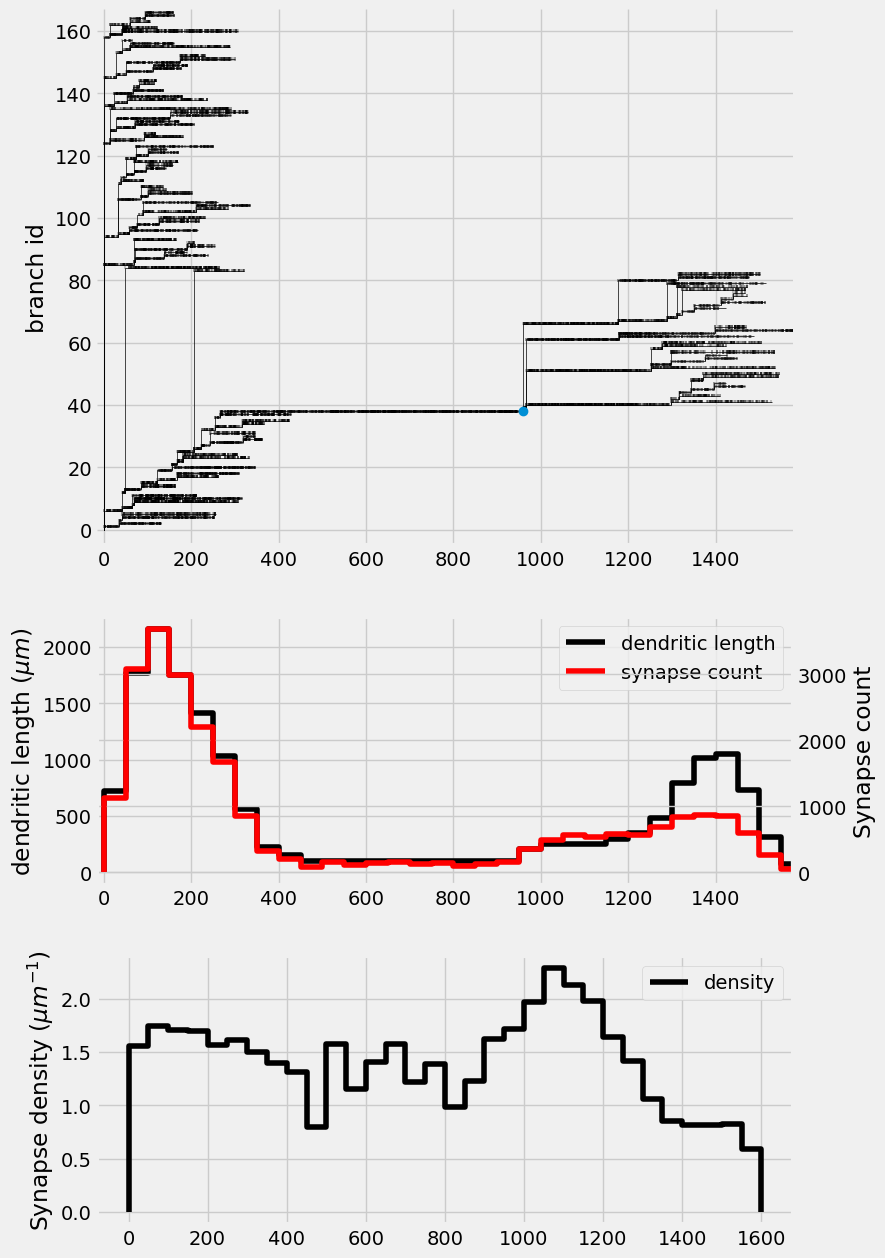

In [ ]:
%matplotlib inline
from visualize.dendrogram import DendrogramStatistics
I.plt.style.use("fivethirtyeight")

dg = DendrogramStatistics(cell)
dg.plot(figsize=(8, 15));

You can also simply plot out the morphology and the synapse locations as a fully featured plot using [CellMorphologyVisualizer](../visualize/cell_morphology_visualizer.py)

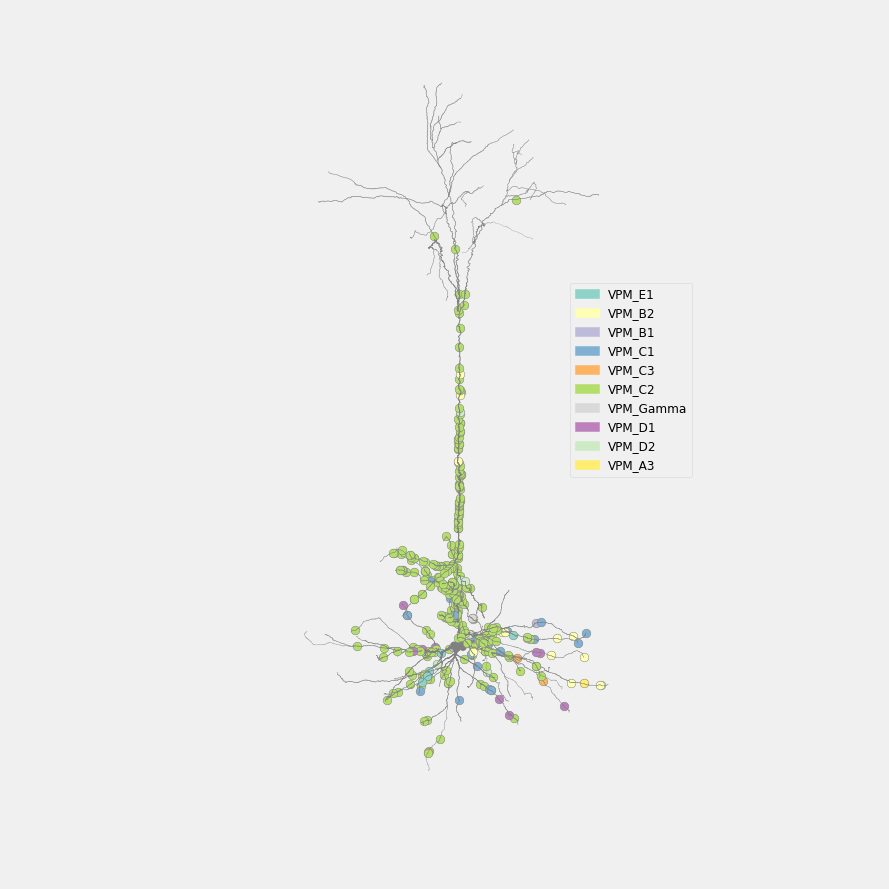

In [101]:
from visualize.cell_morphology_visualizer import CellMorphologyVisualizer
from matplotlib.pyplot import cm

# only show synapses of this type
synapse_filter = "VPM"
show_synapses = [syntype for syntype in cell.synapses if synapse_filter in syntype]
synapse_colors = cm.Set3(I.np.linspace(0, 1, num=len(show_synapses)))

cmv = CellMorphologyVisualizer(cell)
cmv.population_to_color_dict = dict(zip(show_synapses, synapse_colors))
cmv.background_color="#f0f0f0"
fig, ax = cmv.plot(show_synapses=show_synapses, show_legend=True)

## Compatibility with other dense connectome models.

While ISF currently only features one network embedding pipeline ([Udvary et al., 2022](https://doi.org/10.1016/j.celrep.2022.110677)), ISF is not limited to this particular way of generating synapse locations. As long as a [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) file is present (no matter which pipeline created them), any dense connectome model is compatible with ISF. All subsequent workflows in ISF simply rely on these [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) files, but not on the input data that was necessary to generate these. In other words, the barrel cortex model as downloaded in the beginning of this tutorial is simply one example of a network model. Many other dense connectome models may be used. If you have a different way of generating synapse locations, but you still want to use ISF, simply convert the information to [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con). Th file formats are purposfully kept as simple as possible.

## Recap

This tutorial provided a full pipeline on how to generate synapse locations for a given neuron morphology (i.e. an "anatomical network embedding"), and how to parallellize these for multiple morphologies.

In order to assign activity to these synapse realizations, consult the [the next tutorial](./2.2%20Network%20activity.ipynb).